# Does a smaller label set make Jev more accurate?

On the full Banking77 task Jev trails both GPT models (79.0% against 86.2% and 83.9%). The
hypothesis worth testing: **77 options is too many, and Jev does better when the choice is
narrower.**

### The trap in testing this

The obvious experiment - keep only the 7 biggest categories, run it, see a higher number - proves
nothing. A 7-way choice is easier than a 77-way choice by construction: random guessing goes from
1.3% to 14.3%. Accuracy would climb even if the label set made no difference at all.

So this notebook runs **the same 1,001 rows twice**:

| Condition | Rows | Options offered |
| --- | --- | --- |
| `77 labels` | top-7 categories only | all 77 intents |
| `7 labels` | the same rows | only the 7 |

Identical rows, identical prompt, identical models - the only thing that changes is the length of
the option list. Any difference is the effect in question, and because every row is answered under
both conditions the result can be tested pairwise rather than by comparing two averages.

## 1. Setup

In [1]:
# !pip install requests openai pandas pyarrow matplotlib tqdm

In [2]:
import collections
import hashlib
import json
import math
import os
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import requests
from openai import OpenAI
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 5000)

/Users/marie/Documents/github/miptgirl_medium/jev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Paths hang off one anchor so the notebook works whether the kernel starts in `jev/` or at the
repo root - Jupyter and VS Code disagree about that.

In [3]:
# works whether the kernel starts in jev/ or at the repo root
BASE = Path("jev") if Path("jev/data").is_dir() else Path(".")

with open(BASE / ".." / ".." / "config.json") as f:
    config = json.load(f)

JEV_API_KEY = config["JEV_API_KEY"]
openai_client = OpenAI(api_key=config["OPENAI_API_KEY"])

## 2. The data

Both parquet files are pooled - 13,083 rows - and the 7 largest categories are kept. They are
nearly balanced already (213-227 rows each), and we take 143 from each for 1,001 rows exactly
balanced.

Pooling train and test is fine here because nothing is being trained: every call is zero-shot, so
the split boundary carries no meaning for this experiment.

In [4]:
DATASET = "banking77_top7"
TOP_N = 7
PER_CATEGORY = 143  # 7 x 143 = 1,001 rows

train_df = pd.read_parquet(BASE / "data" / "banking77_train.parquet")
test_df = pd.read_parquet(BASE / "data" / "banking77_test.parquet")

# the intent names live in the parquet metadata, not in the data
meta = json.loads(
    pq.ParquetFile(str(BASE / "data" / "banking77_test.parquet"))
    .schema_arrow.metadata[b"huggingface"]
)
ALL_LABELS = meta["info"]["features"]["label"]["names"]

pooled = pd.concat([train_df, test_df], ignore_index=True)
pooled["label"] = pooled["label"].map(lambda i: ALL_LABELS[i])

TOP_LABELS = pooled["label"].value_counts().head(TOP_N).index.tolist()

data = (
    pooled[pooled["label"].isin(TOP_LABELS)]
    .groupby("label", group_keys=False)
    .sample(n=PER_CATEGORY, random_state=42)
    .reset_index(drop=True)
)

print(f"pooled rows : {len(pooled)}")
print(f"sampled     : {len(data)} rows ({PER_CATEGORY} per category)")
print(f"all labels  : {len(ALL_LABELS)}")
print("top categories:")
for label in TOP_LABELS:
    print(f"  {label}")

pooled rows : 13083
sampled     : 1001 rows (143 per category)
all labels  : 77
top categories:
  card_payment_fee_charged
  direct_debit_payment_not_recognised
  balance_not_updated_after_cheque_or_cash_deposit
  wrong_amount_of_cash_received
  cash_withdrawal_charge
  transaction_charged_twice
  declined_cash_withdrawal


Row ids are a hash of the text, not a position, so the cache survives changing `PER_CATEGORY` -
and matches the keys the main Banking77 notebook already wrote.

In [5]:
data["record_id"] = data["text"].map(
    lambda text: hashlib.md5(text.encode()).hexdigest()[:12]
)

INSTRUCTIONS = (
    "Classify this banking customer support message into its intent category. "
    "Choose the single category that best matches what the customer is asking about."
)

records = data[["record_id", "text", "label"]].to_dict(orient="records")
print(f"{len(records)} records ready")

1001 records ready


## 3. The two API calls

Unchanged from the main benchmark. `labels` is a parameter, which is the point here - one function
serves both conditions.

In [6]:
JEV_URL = "https://api.typesafe.ai/v1/systemone"


def call_jev(text, labels, instructions, model="jev-latest"):
    """Ask Jev to pick exactly one label."""
    response = requests.post(
        JEV_URL,
        headers={"Authorization": f"Bearer {JEV_API_KEY}"},
        json={
            "state": text,
            "model": model,
            "questions": {
                "label": {
                    "type": "choice",
                    "instructions": instructions,
                    "criteria": {label: None for label in labels},
                }
            },
        },
        timeout=60,
    )
    response.raise_for_status()
    body = response.json()
    answer = body["answers"]["label"]
    return {
        "prediction": answer["choice"],
        "confidence": answer.get("confidence"),
        "input_tokens": body["usage"]["input_tokens"],
        "output_tokens": body["usage"]["output_tokens"],
    }


def call_openai(text, labels, instructions, model):
    """Ask an OpenAI model the same question, constrained to the same labels."""
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": text},
        ],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "classification",
                "strict": True,
                "schema": {
                    "type": "object",
                    "properties": {"label": {"type": "string", "enum": labels}},
                    "required": ["label"],
                    "additionalProperties": False,
                },
            },
        },
        timeout=60,
    )
    return {
        "prediction": json.loads(response.choices[0].message.content)["label"],
        "confidence": None,  # OpenAI does not give us one
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
    }

## 4. Caching

One JSON file keyed `"<run>|<record_id>"`, only successes stored. The run name carries the
condition, so the 77-label and 7-label answers for the same row never collide.

In [7]:
CACHE_FILE = BASE / "cache" / f"{DATASET}.json"


def load_cache():
    if CACHE_FILE.exists():
        with open(CACHE_FILE) as f:
            return json.load(f)
    return {}


def save_cache(cache):
    CACHE_FILE.parent.mkdir(exist_ok=True)
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=1)


cache = load_cache()
print(f"{len(cache)} answers already cached")

6006 answers already cached


Some of these rows were already answered under the full 77-label list by the main Banking77
notebook, which used the same text-hash keys. Those answers are identical to what we would be
about to buy again, so we copy them across first.

In [8]:
MAIN_CACHE = BASE / "cache" / "banking77.json"
MODELS = ["jev-latest", "gpt-5.6-luna", "gpt-5.6-terra"]

if MAIN_CACHE.exists():
    with open(MAIN_CACHE) as f:
        main_cache = json.load(f)

    borrowed = 0
    for model in MODELS:
        for record in records:
            source = f"{model}|{record['record_id']}"
            target = f"{model} | 77 labels|{record['record_id']}"
            if source in main_cache and target not in cache:
                cache[target] = main_cache[source]
                borrowed += 1

    save_cache(cache)
    print(f"borrowed {borrowed} answers already paid for in the main benchmark")
else:
    print("no main benchmark cache found - nothing to borrow")

borrowed 0 answers already paid for in the main benchmark


In [9]:
def run_model(run_name, call, records, workers=8):
    """Classify every record under one run, skipping whatever is already cached."""

    def classify(record):
        key = f"{run_name}|{record['record_id']}"
        for attempt in range(3):
            try:
                return key, call(record["text"]), None
            except Exception as error:
                message = str(error)
                if "no credits" in message or "insufficient_quota" in message:
                    return key, None, message[:120]
                if attempt == 2:
                    return key, None, message[:120]
                time.sleep(2**attempt)

    todo = [r for r in records if f"{run_name}|{r['record_id']}" not in cache]
    print(f"{run_name}: {len(records) - len(todo)} cached, {len(todo)} to call")

    failures = []
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for key, answer, error in tqdm(pool.map(classify, todo), total=len(todo)):
            if error:
                failures.append(error)
            else:
                cache[key] = answer
    save_cache(cache)

    if failures:
        print(f"  {len(failures)} calls failed, e.g. {failures[0]}")

    return [
        {"record_id": r["record_id"], "label": r["label"], **cache[f"{run_name}|{r['record_id']}"]}
        for r in records
        if f"{run_name}|{r['record_id']}" in cache
    ]

## 5. Run both conditions

Three models times two label sets. The `labels=labels` default argument binds the label set at
definition time - without it every lambda would close over the last one.

In [10]:
LABEL_SETS = {"77 labels": ALL_LABELS, "7 labels": TOP_LABELS}

RUNS = {}
for set_name, labels in LABEL_SETS.items():
    for model in MODELS:
        if model == "jev-latest":
            RUNS[f"{model} | {set_name}"] = (
                lambda text, labels=labels: call_jev(text, labels, INSTRUCTIONS)
            )
        else:
            RUNS[f"{model} | {set_name}"] = (
                lambda text, labels=labels, model=model: call_openai(
                    text, labels, INSTRUCTIONS, model
                )
            )

print(f"{len(RUNS)} runs x {len(records)} records")

6 runs x 1001 records


In [11]:
results = {}
for run_name, call in RUNS.items():
    results[run_name] = run_model(run_name, call, records)

jev-latest | 77 labels: 1001 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

gpt-5.6-luna | 77 labels: 1001 cached, 0 to call


0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

gpt-5.6-terra | 7 labels: 1001 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

## 6. Did the smaller label set help?

In [12]:
def wilson_interval(correct, total, z=1.96):
    """95% confidence interval for an accuracy figure."""
    if total == 0:
        return 0.0, 0.0
    p = correct / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    margin = z * math.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return round(max(0, centre - margin), 4), round(min(1, centre + margin), 4)


rows = []
for run_name, answers in results.items():
    if not answers:
        print(f"{run_name}: no answers")
        continue
    model, label_set = run_name.split(" | ")
    correct = sum(a["prediction"] == a["label"] for a in answers)
    low, high = wilson_interval(correct, len(answers))
    rows.append(
        {
            "model": model,
            "label_set": label_set,
            "answered": len(answers),
            "correct": correct,
            "accuracy": round(correct / len(answers), 4),
            "ci_low": low,
            "ci_high": high,
            "input_tokens": sum(a["input_tokens"] or 0 for a in answers),
            "output_tokens": sum(a["output_tokens"] or 0 for a in answers),
        }
    )

scores = pd.DataFrame(rows)
scores.sort_values(["model", "label_set"]).reset_index(drop=True)

,model,label_set,answered,correct,accuracy,ci_low,ci_high,input_tokens,output_tokens
0,gpt-5.6-luna,7 labels,1001,979,0.9780,0.9669,0.9854,132830,31487
1,gpt-5.6-luna,77 labels,1001,892,0.8911,0.8703,0.9089,479176,39545
2,gpt-5.6-terra,7 labels,1001,980,0.9790,0.9681,0.9862,132830,25482
3,gpt-5.6-terra,77 labels,1001,889,0.8881,0.8671,0.9062,479176,24299
4,jev-latest,7 labels,1001,979,0.9780,0.9669,0.9854,398615,114146
5,jev-latest,77 labels,1001,835,0.8342,0.8099,0.8559,1046262,831373


### The paired test

Both conditions ran on the same rows, so the right question is not whether two averages differ but
whether the **same rows flipped**. `fixed_by_7` counts rows the narrower list rescued,
`broken_by_7` counts rows it cost. McNemar asks whether that split is too lopsided to be chance.

In [13]:
def paired_test(rows_a, rows_b):
    """McNemar on two runs over the same rows."""
    a = {r["record_id"]: r["prediction"] == r["label"] for r in rows_a}
    b = {r["record_id"]: r["prediction"] == r["label"] for r in rows_b}
    shared = set(a) & set(b)

    a_only = sum(1 for i in shared if a[i] and not b[i])
    b_only = sum(1 for i in shared if not a[i] and b[i])

    n = a_only + b_only
    if n == 0:
        return a_only, b_only, 1.0, len(shared)
    k = min(a_only, b_only)
    p = min(1.0, 2 * sum(math.comb(n, i) for i in range(k + 1)) / 2**n)
    return a_only, b_only, p, len(shared)


comparison = []
for model in MODELS:
    wide = results.get(f"{model} | 77 labels")
    narrow = results.get(f"{model} | 7 labels")
    if not wide or not narrow:
        continue

    fixed, broken, p_value, shared = paired_test(narrow, wide)

    # score both arms on the shared rows only, so the two numbers are comparable
    shared_ids = {a["record_id"] for a in wide} & {a["record_id"] for a in narrow}
    wide_rows = [a for a in wide if a["record_id"] in shared_ids]
    narrow_rows = [a for a in narrow if a["record_id"] in shared_ids]

    comparison.append(
        {
            "model": model,
            "n_shared": shared,
            "acc_77": round(sum(a["prediction"] == a["label"] for a in wide_rows) / shared, 4),
            "acc_7": round(sum(a["prediction"] == a["label"] for a in narrow_rows) / shared, 4),
            "fixed_by_7": fixed,
            "broken_by_7": broken,
            "p_value": round(p_value, 6),
            "verdict": "real" if p_value < 0.05 else "chance",
        }
    )

paired = pd.DataFrame(comparison)
if not paired.empty:
    paired["change"] = (paired["acc_7"] - paired["acc_77"]).round(4)
paired

,model,n_shared,acc_77,acc_7,fixed_by_7,broken_by_7,p_value,verdict,change
0,jev-latest,1001,0.8342,0.978,145,1,0.0,real,0.1438
1,gpt-5.6-luna,1001,0.8911,0.978,88,1,0.0,real,0.0869
2,gpt-5.6-terra,1001,0.8881,0.979,91,0,0.0,real,0.0909


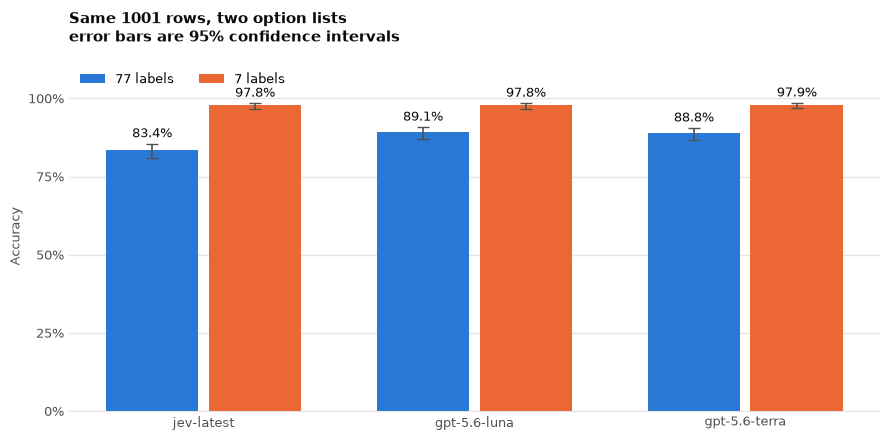

In [14]:
if not scores.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))

    label_sets = ["77 labels", "7 labels"]
    colors = {"77 labels": "#2a78d6", "7 labels": "#eb6834"}
    width = 0.38

    for i, label_set in enumerate(label_sets):
        subset = (
            scores[scores["label_set"] == label_set].set_index("model").reindex(MODELS)
        )
        positions = [x + i * width for x in range(len(MODELS))]
        lower = subset["accuracy"] - subset["ci_low"]
        upper = subset["ci_high"] - subset["accuracy"]
        ax.bar(
            positions, subset["accuracy"], width=width * 0.9,
            color=colors[label_set], label=label_set,
            yerr=[lower, upper], capsize=4,
            error_kw={"ecolor": "#52514e", "elinewidth": 1.2},
        )
        for position, value, high in zip(positions, subset["accuracy"], subset["ci_high"]):
            if pd.notna(value):
                ax.text(
                    position, high + 0.02, f"{value:.1%}",
                    ha="center", color="#0b0b0b", fontsize=9,
                )

    ax.set_xticks([x + width / 2 for x in range(len(MODELS))])
    ax.set_xticklabels(MODELS, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.set_ylabel("Accuracy", color="#52514e", fontsize=9)
    ax.yaxis.grid(True, color="#e6e5e1", linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#52514e", labelsize=9, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#e6e5e1")
    ax.legend(frameon=False, fontsize=9, loc="upper left", ncol=2)
    ax.set_title(
        f"Same {len(records)} rows, two option lists\n"
        "error bars are 95% confidence intervals",
        color="#0b0b0b", fontsize=11, fontweight="bold", loc="left", pad=14,
    )
    fig.tight_layout()
    plt.show()

## 7. Where the 77-label runs lose their answers

Every row here genuinely belongs to one of the 7 categories, so a mistake under the full list is
one of two kinds:

- it picked one of the **other 70** intents - a mistake the 7-label condition makes impossible
- it picked a **wrong one of the 7** - a mistake narrowing the list cannot fix

The split between them is the ceiling on how much this hypothesis can buy.

In [15]:
leak_rows = []
for model in MODELS:
    answers = results.get(f"{model} | 77 labels")
    if not answers:
        continue
    mistakes = [a for a in answers if a["prediction"] != a["label"]]
    outside = [a for a in mistakes if a["prediction"] not in TOP_LABELS]
    leak_rows.append(
        {
            "model": model,
            "mistakes": len(mistakes),
            "picked_outside_top7": len(outside),
            "picked_wrong_within_top7": len(mistakes) - len(outside),
            "share_outside": round(len(outside) / len(mistakes), 2) if mistakes else None,
        }
    )

pd.DataFrame(leak_rows)

,model,mistakes,picked_outside_top7,picked_wrong_within_top7,share_outside
0,jev-latest,166,159,7,0.96
1,gpt-5.6-luna,109,99,10,0.91
2,gpt-5.6-terra,112,102,10,0.91


In [16]:
for model in MODELS:
    answers = results.get(f"{model} | 77 labels")
    if not answers:
        continue
    mistakes = [a for a in answers if a["prediction"] != a["label"]]
    print(f"\n=== {model} (77 labels): {len(mistakes)} mistakes ===")
    for (true_label, predicted), count in collections.Counter(
        (a["label"], a["prediction"]) for a in mistakes
    ).most_common(8):
        marker = " " if predicted in TOP_LABELS else "*"
        print(f"  {marker} {count}x  {true_label}  ->  {predicted}")

print("\n* = a label outside the top-7, which the 7-label condition rules out by construction")


=== jev-latest (77 labels): 166 mistakes ===
  * 45x  direct_debit_payment_not_recognised  ->  card_payment_not_recognised
  * 28x  card_payment_fee_charged  ->  extra_charge_on_statement
  * 12x  declined_cash_withdrawal  ->  atm_support
  * 10x  declined_cash_withdrawal  ->  card_not_working
  * 8x  direct_debit_payment_not_recognised  ->  extra_charge_on_statement
  * 6x  balance_not_updated_after_cheque_or_cash_deposit  ->  top_up_by_cash_or_cheque
  * 5x  balance_not_updated_after_cheque_or_cash_deposit  ->  balance_not_updated_after_bank_transfer
    5x  wrong_amount_of_cash_received  ->  declined_cash_withdrawal

=== gpt-5.6-luna (77 labels): 109 mistakes ===
  * 42x  direct_debit_payment_not_recognised  ->  card_payment_not_recognised
  * 13x  card_payment_fee_charged  ->  extra_charge_on_statement
    7x  wrong_amount_of_cash_received  ->  declined_cash_withdrawal
  * 6x  direct_debit_payment_not_recognised  ->  request_refund
  * 5x  wrong_amount_of_cash_received  ->  pendin

## 8. Cost

Jev returns a probability for every option, so a shorter list should mean a shorter response.
Worth knowing whether narrowing is cheaper as well as (possibly) more accurate.

In [17]:
cost = scores.copy()
cost["in_per_call"] = (cost["input_tokens"] / cost["answered"]).round(0)
cost["out_per_call"] = (cost["output_tokens"] / cost["answered"]).round(0)
cost[["model", "label_set", "accuracy", "in_per_call", "out_per_call"]].sort_values(
    ["model", "label_set"]
).reset_index(drop=True)

,model,label_set,accuracy,in_per_call,out_per_call
0,gpt-5.6-luna,7 labels,0.9780,133.0,31.0
1,gpt-5.6-luna,77 labels,0.8911,479.0,40.0
2,gpt-5.6-terra,7 labels,0.9790,133.0,25.0
3,gpt-5.6-terra,77 labels,0.8881,479.0,24.0
4,jev-latest,7 labels,0.9780,398.0,114.0
5,jev-latest,77 labels,0.8342,1045.0,831.0


## 9. Confidence

If a narrower list makes Jev more certain as well as more accurate, it shows up here.

In [18]:
confident = [
    {**a, "run": run_name}
    for run_name, answers in results.items()
    for a in answers
    if a.get("confidence") is not None
]

if not confident:
    print("No confidence values returned.")
else:
    frame = pd.DataFrame(confident)
    frame["correct"] = frame["prediction"] == frame["label"]
    frame[["model", "label_set"]] = frame["run"].str.split(" | ", expand=True, regex=False)
    display(
        frame.groupby(["model", "label_set"])[["confidence", "correct"]]
        .mean()
        .round(3)
        .reset_index()
    )

,model,label_set,confidence,correct
0,jev-latest,7 labels,0.982,0.978
1,jev-latest,77 labels,0.891,0.834


## 10. Save

In [19]:
RESULTS = BASE / "results"
RESULTS.mkdir(exist_ok=True)

if results:
    flat = pd.DataFrame(
        [{**a, "run": run_name} for run_name, answers in results.items() for a in answers]
    )
    flat.to_csv(RESULTS / f"{DATASET}_predictions.csv", index=False)
    scores.to_csv(RESULTS / f"{DATASET}_summary.csv", index=False)
    print(f"wrote {RESULTS}/{DATASET}_predictions.csv ({len(flat)} rows)")

wrote results/banking77_top7_predictions.csv (6006 rows)


## Notes

- **Read the paired table, not the bar chart.** Both conditions ran on the same rows, so
  `fixed_by_7` against `broken_by_7` is the evidence. Two averages can move for reasons the
  pairing controls for.
- **These numbers are not the full-task numbers.** Accuracy here is on a 7-category subset and is
  not comparable to the 79.0% / 86.2% / 83.9% from the 1,000-row Banking77 run. The comparison
  that means something is `77 labels` against `7 labels` *within* this notebook.
- **If narrowing helps, it is a deployment lever, not a benchmark result.** It would say that when
  you already know which categories are plausible for a message, telling the model so is worth
  doing - a real thing to act on in production, but not a statement about the model in general.
- **Train and test are pooled** because nothing is trained here; every call is zero-shot.